In [1]:
import sys, importlib
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import itertools
import time
import pickle
import os
import seaborn as sns 
import warnings
import scipy.stats as stats
import matplotlib

# Set the working directory to the Code_ACC project directory
# dirc_server='Code_ACC/'
# os.chdir(dirc_server)

In [2]:
import pkg_resources

for dist in pkg_resources.working_set:
    print(f"{dist.project_name} - {dist.version}", end="")

tzdata - 2024.1pytz - 2024.1pyarrow - 14.0.2nvidia-nvtx-cu12 - 12.4.127nvidia-cuda-runtime-cu12 - 12.4.127nvidia-cuda-cupti-cu12 - 12.4.127nvidia-nvjitlink-cu12 - 12.4.127nvidia-cuda-nvrtc-cu12 - 12.4.127nvidia-cublas-cu12 - 12.4.5.8nvidia-cusparse-cu12 - 12.3.1.170nvidia-cusolver-cu12 - 11.6.1.9nvidia-cufft-cu12 - 11.2.1.3nvidia-curand-cu12 - 10.3.5.147nvidia-cudnn-cu12 - 9.1.0.70fonttools - 4.51.0typing-extensions - 4.12.2pycryptodomex - 3.20.0h5py - 3.11.0matplotlib - 3.8.4threadpoolctl - 3.5.0triton - 3.2.0pyparsing - 3.1.2loss-landscapes - 3.0.6nvidia-nccl-cu12 - 2.21.5numexpr - 2.10.1torch - 2.6.0pandas - 2.2.1sklearn-pandas - 2.2.0ecos - 2.0.13numpy - 1.26.4wrapt - 1.16.0sympy - 1.13.1scipy - 1.13.0texttable - 1.7.0autograd - 1.6.2kiwisolver - 1.4.5joblib - 1.4.2scikit-learn - 1.3.2interface-meta - 1.3.0contourpy - 1.2.1Brotli - 1.1.0pyppmd - 1.1.0pybcj - 1.0.2formulaic - 1.0.1inflate64 - 1.0.0future - 1.0.0numba - 0.60.0llvmlite - 0.43.0lifelines - 0.28.0scikit-survival - 0.22.

In [3]:
# Load local defined functions
try:
    importlib.reload(sys.modules['func'])
except:
    pass
# Load local defined functions
from func_acc import get_result

In [4]:
lr = 0
lr_decrease = 'epoch'
default_loc_simulation = "Results/n"

result_2048 = pd.DataFrame()
for b in [4,8,16,32,64,128,256,512]:
    result_2048_tmp = get_result(2048,10,b,lr,lr_decrease,200,200,default_loc = default_loc_simulation)
    result_2048 = pd.concat([result_2048,result_2048_tmp])

In [5]:
result_2048_filter = result_2048[result_2048['variable'].isin(['SBGD', 'FBGD','CoxPH','CoxPH-strata'])].copy()
tmp = pd.Categorical(result_2048_filter['variable'], categories=['FBGD','CoxPH-strata','SBGD','CoxPH'])
result_2048_filter['variable'] = tmp.rename_categories({'FBGD': 'SGD-FB', 'SBGD': 'SGD-SB'})

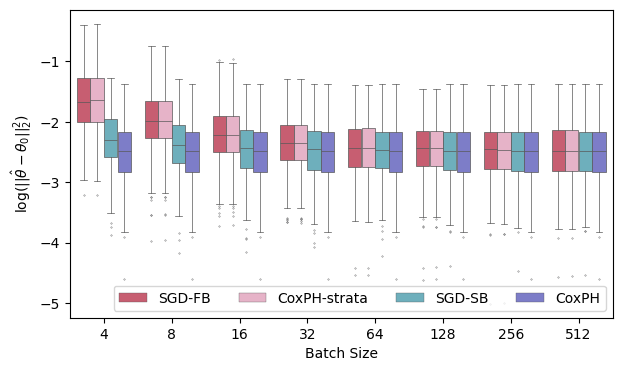

In [6]:
palette = ["#d94c66","#EFAAC7","#61B8C9","#7070D5"]

fig = plt.figure(figsize=(7, 4))
plt1 = sns.boxplot(x = result_2048_filter['batch_size'], 
                   y = result_2048_filter['value'], 
                   hue = result_2048_filter['variable'],
                   palette = palette,
                   flierprops={'marker': 'o','markersize': 0.3, 'markerfacecolor': '#D5D5E7'},
                   linewidth=.5)
plt1.set(title=None,
         ylabel = r'$\log(||\hat{\theta}-\theta_0||_2^2)$',
         xlabel = 'Batch Size')
plt1.legend(ncol=4,loc = 'lower right')

plt.savefig('Figure/PH-reg-simulation.png',bbox_inches='tight', dpi=300)